# YOLO26-SAM2 Surgical Tool Instance Segmentation for Laparoscopic Surgery
> **Final Project by Cristina Kennedy, BSN, RN**
>
> Harvard Extension School<br>
> CSCIE-25 Computer Vision<br>
> May 2026

# 1.0 Introduction
As the surgical field advances and minimally invasive surgeries, including robotic surgeries, become more common, there is a new opportunity to create semi-autonomous or even autonomous surgical systems. Precise instance segmentation of surgical tools is essential to achieving this goal.

This project proposes developing an end-to-end computer vision pipeline that accurately segments surgical instruments in laparoscopic cholecystectomy (gallbladder removal) video frames to support computer-assisted surgical interventions. I would like to investigate the extent to which fine-tuning [YOLO26](https://docs.ultralytics.com/models/yolo26) model can achieve high instance segmentation accuracy across all laparoscopic surgical tool classes, including rare and visually similar instruments, compared to Mask R-CNN and Mask2Former models used in the initial study. I would also like to explore how class imbalance among surgical tool categories affects per-class segmentation performance, and to what extent targeted augmentation strategies can mitigate this effect.

I also included [SAM2](https://ai.meta.com/research/sam2/) specifically for its high-quality masks, fine-tuning, and its compatibility with YOLO26. Although these two models can't be benchmarked using the same metrics in a traditional sense, they are able to work together to combine localization and mask quality. 

## 1.1 Dataset Description
The [CholecInstanceSeg](https://www.synapse.org/Synapse:syn60239970/wiki/628710) dataset is a surgical tool instance segmentation dataset comprising 41,933 annotated frames extracted from 85 laparoscopic cholecystectomy procedures, with 64,400 tool instances, each labeled with a semantic mask and an instance ID, across seven instrument classes:
* Grasper
* Bipolar
* Hook
* Clipper
* Scissors
* Irrigator
* Snare.
   
A comprehensive assessment of the dataset, including the labeling process, can be found in the [Nature paper](https://www.nature.com/articles/s41597-025-05163-w) published alongside it. According to Synapse, this is the largest open-access tool instance segmentation dataset to date. CholecInstanceSeg is well-suited for this project, as it provides instance-level annotations, which are critical given the goal of instance segmentation. Training on pixel-level instance masks directly aligns with what YOLO26-seg is optimized to learn.
The dataset comes with predefined train/val/test splits as specified by the dataset authors. These splits are used as-is, following the authors' recommendation to preserve the intended data distribution:
* Train set: 26830 images
* Val set: 4284 images
* Test set: 10819 images.

## 1.2 Results
#### Part 1
One of my goals was to compare how YOLO26 does against [Mask-RCNN and Mask2former models](https://www.nature.com/articles/s41597-025-05163-w/tables/3) from the original study. The evaluation metric used across all models is mAP(50-95). The `YOLO26` models are fine-tuned on the CholeInstanceSeg dataset: `yolo_baseline` as-is, and `yolo_augmented` upgraded with a custom augmentation pipeline.

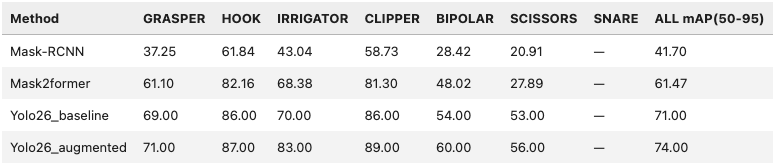

The first fine-tuned YOLO26 `yolo_baseline` I used as a baseline model already did much better than both models tested in the original study. For `yolo26_augmented`, I added a custom augmentation pipeline that outperformed all 3 models. The greatest improvements can be seen particularly in the classes with less data.

#### Part 2
One of the challenges I encountered was making a fair comparison between the SAM2 and YOLO26 (yolo_augmented), since both models produce different native inference metrics. The easiest path for me was to evaluate both using the SAM2's own `sav_evaluator`. It compares the predicted mask colored by index, called palette PNGs, to the ground truth palette PNGs. Since SAM2 already predicts in that format, all I needed to do was export YOLO26's outputs as palette PNGs, at which point the same evaluator could score both models on the same metrics. All three models were evaluated on the same test dataset.

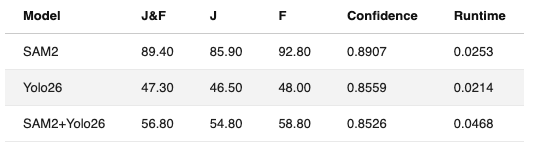

SAM2 did significantly better than YOLO26 in segmentation quality, at the cost of slightly slower inference time. I had high hopes for the SAM2+Yolo26 model, but it performed worse compared to SAM2 alone, while being twice as slow. 

# 2.0 Data Preparation
> In the following section I am doing data preparation needed for training and evaluation. It mainly entails creating and organizing data paths, and loading labels in the format each of my models expects.

In [1]:
# import required libraries
import os
import zipfile
import shutil
import json
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as pltimg
from matplotlib.colors import ListedColormap
import torch
import torchvision

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# copy dataset from drive to local
print('Downloading dataset from Google Drive...')
drive_path = '/content/drive/MyDrive/Surg_Data/original_dataset.zip'
shutil.copy(drive_path, 'original_dataset.zip')

# unzip dataset
print('Done! Extracting files...')
with zipfile.ZipFile('original_dataset.zip', 'r') as z:
  z.extractall()

print('Done!')


Done! Extracting files...
Done!


In [4]:
# create individual paths for every subfolder
ANN_ROOT = 'original_dataset/cholecinstanceseg'
ANN_TRAIN = os.path.join(ANN_ROOT, 'train')
ANN_VAL   = os.path.join(ANN_ROOT, 'val')
ANN_TEST  = os.path.join(ANN_ROOT, 'test')

IMG_ROOT = 'original_dataset/cholecinstance_seg_reference_image_set'
IMG_TRAIN = os.path.join(IMG_ROOT, 'train')
IMG_VAL   = os.path.join(IMG_ROOT, 'val')
IMG_TEST  = os.path.join(IMG_ROOT, 'test')

# create data path for converted YOLO dataset
YOLO_ROOT = 'dataset'
IMG_YOLO_ROOT = os.path.join(YOLO_ROOT, 'images')
IMG_SAM2_ROOT = os.path.join(YOLO_ROOT, 'sam2images')
ANN_YOLO_ROOT = os.path.join(YOLO_ROOT, 'labels')
ANN_SAM2_ROOT = os.path.join(YOLO_ROOT, 'sam2labels')

In [5]:
# find the training files
def find_files(img_root, ann_root):
  dirs = [
      d
      for d in os.listdir(img_root)
      if os.path.isdir(os.path.join(img_root, d))
    ]

  all_images = []
  all_annotations = []
  for dir in dirs:
    imgs = [os.path.join(img_root, dir, 'img_dir', filename) for filename in sorted(os.listdir(os.path.join(img_root, dir, 'img_dir')))]
    anns = [os.path.join(ann_root, dir, 'ann_dir', filename) for filename in sorted(os.listdir(os.path.join(ann_root, dir, 'ann_dir')))]

    all_images = all_images + imgs
    all_annotations = all_annotations + anns

  return all_images, all_annotations

# create paths to all images in each set, count and print findings
train_images, train_annotations = find_files(IMG_TRAIN, ANN_TRAIN)
print(f'Found {len(train_images)} TRAIN images')

val_images, val_annotations = find_files(IMG_VAL, ANN_VAL)
print(f'Found {len(val_images)} VAL images')

test_images, test_annotations = find_files(IMG_TEST, ANN_TEST)
print(f'Found {len(test_images)} TEST images')


Found 26830 TRAIN images
Found 4284 VAL images
Found 10819 TEST images


In [6]:
def load_image(img_path, type):
    # copy images from original dataset into YOLO dataset for train/val/test
    name = os.path.basename(img_path)
    shutil.copy2(img_path, os.path.join(IMG_YOLO_ROOT, type, name))

    # also save image into sam2 dataset and convert to jpg
    img = Image.open(img_path)
    output_path = os.path.join(IMG_SAM2_ROOT, type, name)
    os.makedirs(output_path)
    img.save(os.path.join(output_path, '1.jpg'), "JPEG")

print('Loading images and building dataset')

os.makedirs(os.path.join(IMG_YOLO_ROOT, 'train'), exist_ok=True)
[load_image(img,'train') for img in train_images]
print('Finished training data..')

os.makedirs(os.path.join(IMG_YOLO_ROOT, 'val'), exist_ok=True)
[load_image(img,'val') for img in val_images]
print('Finished validation data..')

os.makedirs(os.path.join(IMG_YOLO_ROOT, 'test'), exist_ok=True)
[load_image(img,'test') for img in test_images]
print('Finished testing data..')

print('Done!')

Loading images and building dataset
Finished training data..
Finished validation data..
Finished testing data..
Done!


In [7]:
# define classes
classes = ['grasper', 'bipolar', 'hook', 'clipper', 'scissors', 'irrigator', 'snare']

# copy annotations from the original dataset and convert them into yolo labels
def load_annotation(ann_path, type):
    name = os.path.basename(ann_path)
    output_path = os.path.join(ANN_YOLO_ROOT, type, name.replace('.json', '.txt'))
    # open json file
    with open(ann_path, 'r', encoding='utf-8') as file:
        annotation = json.load(file)

        name_image = name.replace('.json','.png')
        image = cv2.imread(os.path.join(IMG_YOLO_ROOT, type, name_image))
        height, width, channels = image.shape

        # calculate yolo data points from masks
        data = annotation['shapes']
        arr = np.zeros((height, width), dtype=np.uint8)
        sam2_ann_path = os.path.join(ANN_SAM2_ROOT, type, name_image)
        sam2_img_path = os.path.join(IMG_SAM2_ROOT, type, name_image)

        if len(data) > 0:
            with open(output_path, 'w', encoding='utf-8') as output:
                for i, mask in enumerate(data):
                    line = ''
                    tool = mask['label']
                    tool_id = classes.index(tool)
                    points = mask['points']

                    line = str(tool_id)
                    for x, y in points:
                        line = f'{line} {x / width} {y / height}'

                    # create .txt file for yolo
                    print(line, file=output)

                    # create sam2 mask png
                    # sam2 masks must be filled, not just outline polygons
                    contour = np.array(points).reshape(-1, 1, 2).astype(np.int32)
                    cv2.fillPoly(arr, [contour], color=i+1)

            # create one image with 'palette' format (multiple masks in one image)
            img = Image.fromarray(arr.astype(np.uint8))
            img = img.convert("P")

            sam2path = os.path.join(ANN_SAM2_ROOT, type, name_image)
            os.makedirs(sam2path, exist_ok=True)
            img.save(os.path.join(sam2path, '1.png'))
        elif type == 'train' or type == 'val':
            # remove annotations with no objects from sam2 training set
            shutil.rmtree(sam2_img_path)

print('Loading annotations -> yolo + sam2')

# loading annotations for each of the three datasets
os.makedirs(os.path.join(ANN_YOLO_ROOT, 'train'), exist_ok=True)
os.makedirs(os.path.join(ANN_SAM2_ROOT, 'train'), exist_ok=True)
[load_annotation(ann,'train') for ann in train_annotations]
print('Finished training data..')

os.makedirs(os.path.join(ANN_YOLO_ROOT, 'val'), exist_ok=True)
os.makedirs(os.path.join(ANN_SAM2_ROOT, 'val'), exist_ok=True)
[load_annotation(ann,'val') for ann in val_annotations]
print('Finished validation data..')

os.makedirs(os.path.join(ANN_YOLO_ROOT, 'test'), exist_ok=True)
os.makedirs(os.path.join(ANN_SAM2_ROOT, 'test'), exist_ok=True)
[load_annotation(ann,'test') for ann in test_annotations]
print('Finished test data..')

print('Done!')

Loading annotations -> yolo + sam2
Finished training data..
Finished validation data..
Finished test data..
Done!


In [8]:
# load YOLO annotations from a .txt file
import random
def load_yolo_labels(label_path):
    masks = []
    cls = []
    if not label_path.exists():
        return cls, masks

    with open(label_path, "r") as f:
        for line in f.readlines():
            parts = line.strip().split()

            # class if first part, separate it from xy
            tool_id = parts[0]
            parts = parts[1:]

            xy = list(zip(parts[0::2], parts[1::2]))
            masks.append(xy)
            cls.append(tool_id)

    return cls, masks

# draw YOLO-format masks on an image
def draw_yolo_masks(img, masks, class_names=None, color=(255, 0, 0)):
    h, w = img.shape[:2]

    for shape in masks:
        # de-normalize coordinates to x,y space
        pts = [(float(x) * w, float(y) * h) for x, y in shape]
        # draw mask onto its image
        pts = np.array(pts, np.int32)
        pts.reshape((-1, 1, 2))
        cv2.polylines(img, [pts], True, color, thickness=3)

    return img

# sample and display 4 images
def sample_and_display(
    images_dir,
    labels_dir,
    sam2_dir,
    n=4,
    class_names=None,
    seed=42
):
    random.seed(seed)

    images_dir = Path(images_dir)
    labels_dir = Path(labels_dir)
    sam2_dir = Path(sam2_dir)

    image_files = list(images_dir.glob("*.jpg")) + \
                  list(images_dir.glob("*.png")) + \
                  list(images_dir.glob("*.jpeg"))

    sample = random.sample(image_files, min(n, len(image_files)))

    for img_path in sample:
        label_path = labels_dir / (img_path.stem + ".txt")
        sam2_label_path = sam2_dir / img_path.name / '1.png'

        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        cls, boxes = load_yolo_labels(label_path)
        img = draw_yolo_masks(img, boxes, class_names)

        fig, (ax1, ax2) = plt.subplots(1, 2)
        ax1.imshow(img)
        ax1.axis('off')
        ax2.axis('off')

        print(sam2_label_path)
        if os.path.exists(sam2_label_path):
            ax2.imshow(np.array(Image.open(sam2_label_path)))

        # plt.figure(figsize=(7, 7))
        # plt.imshow(img)
        plt.title(img_path.name)
        plt.show()

In [ ]:
# create the data.yaml file for yolo
with open(os.path.join(YOLO_ROOT, 'data.yaml'), 'w') as yaml:
    # print('path: /content/drive/MyDrive/Surg_Data/dataset', file=yaml)
    # print('path: /Users/queen_c/Desktop/1. Computer Vision/Project/dataset', file=yaml)
    print('path: dataset', file=yaml)
    print('train: images/train', file=yaml)
    print('val: images/val', file=yaml)
    print('test: images/test', file=yaml)
    print('', file=yaml)
    print(f'nc: {len(classes)}', file=yaml)
    print(f'names: {classes}', file=yaml)



# 3.0 Exploratory Data Analysis
> Before I go any further, I would like to do some exploratory data analysis. After an offline analysis of the data, I noticed that not every image contains a surgical tool. I will do a sanity check to look at the number of images with annotations vs empty label files across the whole dataset. I am also interested in the distribution of tool classes and the average number of instances per image.

Total images with annotations: 37019
Empty label files: 0
Average instances per image: 1.81
Max # of masks in one image: 6

Class counts: {'grasper': 40172, 'bipolar': 2884, 'hook': 19429, 'clipper': 1399, 'scissors': 715, 'irrigator': 2443, 'snare': 43}


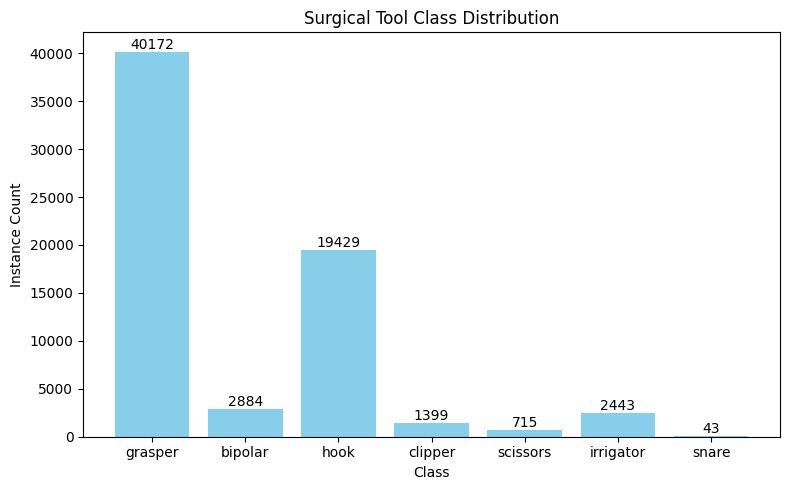

In [ ]:
# define classes
classes = ['grasper', 'bipolar', 'hook', 'clipper', 'scissors', 'irrigator', 'snare']

class_count = {c: 0 for c in classes}
empty_files = []
mask_counts = []

# count instances of each class across all masks in the label files
for root, dirs, files in os.walk(ANN_YOLO_ROOT):
    for file in files:
        if file.endswith('.txt'):
            filepath = os.path.join(root, file)
            with open(filepath, 'r') as f:
                lines = [l.strip() for l in f if l.strip()]
                if not lines:
                    empty_files.append(file)
                    continue
                mask_counts.append(len(lines))
                # the first value in each mask is the class by index
                for line in lines:
                    vals = line.split(' ')
                    i = int(vals[0])
                    c = classes[i]
                    class_count[c] += 1

print(f"Total images with annotations: {len(mask_counts)}")
print(f"Empty label files: {len(empty_files)}")
if mask_counts:
    print(f"Average instances per image: {sum(mask_counts)/len(mask_counts):.2f}")
    print(f"Max # of masks in one image: {max(mask_counts)}")
print(f"\nClass counts: {class_count}")

# plot the data
names  = list(class_count.keys())
counts = list(class_count.values())

plt.figure(figsize=(8, 5))
bars = plt.bar(names, counts, color='skyblue')
plt.bar_label(bars)
plt.xlabel('Class')
plt.ylabel('Instance Count')
plt.title('Surgical Tool Class Distribution')
plt.tight_layout()
plt.show()

#### Class Imbalance
> There is a severe class imbalance between instances of surgical tools. The majority of frames contain one or two tools, with a maximum of six tools per frame. There are approximately 4914 frames (about one-eighth of the dataset) that contain no tools. The grasper dominates by a long shot, which will pose a big challenge in model training and accuracy/loss calculations. I will address these challenges through modifications to the loss function and custom augmentations later in the project.

> Next, I will sample and display a few images to visualize the ground truth YOLO and SAM2 segmentation masks to ensure they work as intended. Yolo on the left, SAM2 on the right.

dataset/sam2labels/train/t50_VID27_000843.png/1.png


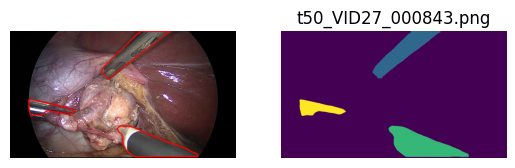

dataset/sam2labels/train/t50_VID43_000606.png/1.png


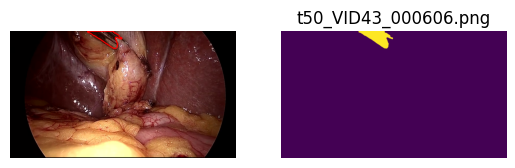

dataset/sam2labels/train/t50_VID25_000258.png/1.png


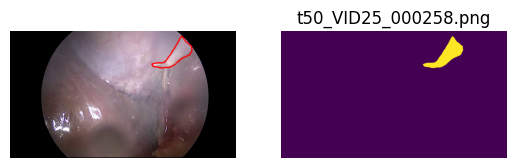

dataset/sam2labels/train/seg8k_video43_000558.png/1.png


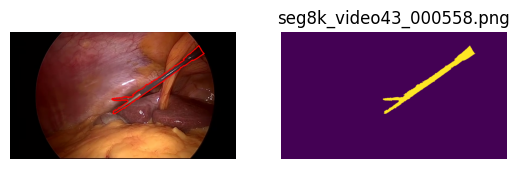

In [ ]:
sample_and_display(os.path.join(IMG_YOLO_ROOT, 'train'), os.path.join(ANN_YOLO_ROOT, 'train'), os.path.join(ANN_SAM2_ROOT, 'train'))

# `4.0 Model 1: Fine-tuned YOLO26`
### 4.1 Training

> The first model is `YOLO26` fine-tuned on the CholeInstanceSeg dataset using the default Ultralytics training configuration. This will also serve as the baseline for the instance segmentation performance of future models.

In [16]:
#install yolo dependancies
!pip install ultralytics
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 43.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# load a COCO-pretrained YOLO26n model
model = YOLO('yolo26m-seg.pt')

# train the baseline model on the CholecInstanceSeg
results_yolo = model.train(
    data=os.path.join(YOLO_ROOT, 'data.yaml'),
    epochs=50,
    imgsz=640,
    batch=16,
    project='/content/drive/MyDrive/Surg_Data',
    name='yolo26_baseline'
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26_baseline, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True

### 4.2 Evaluation

In [ ]:
# load the last checkpoint
model = YOLO('/content/drive/MyDrive/Surg_Data/yolo26_baseline/weights/last.pt')

# load the baseline training log data
metrics_df = pd.read_csv("/content/drive/MyDrive/Surg_Data/yolo26_baseline/results.csv")
metrics_df.head()

,epoch,time,train/box_loss,train/seg_loss,train/cls_loss,train/dfl_loss,train/sem_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),...,val/dfl_loss,val/sem_loss,lr/pg0,lr/pg1,lr/pg2,lr/pg3,lr/pg4,lr/pg5,lr/pg6,lr/pg7
0,1,929.311,0.75045,1.11234,1.41304,0.00502,0.81499,0.77901,0.65351,0.72205,...,0.00693,0,0.009994,0.003331,0.009994,0.003331,0.009994,0.003331,0.009994,0.003331
1,2,1646.230,0.75335,0.97387,0.65645,0.00507,0.27295,0.70462,0.69717,0.71896,...,0.00805,0,0.019598,0.006533,0.019598,0.006533,0.019598,0.006533,0.019598,0.006533
2,3,2292.210,0.83078,1.01499,0.69032,0.00578,0.29567,0.66089,0.54898,0.56746,...,0.01019,0,0.028806,0.009602,0.028806,0.009602,0.028806,0.009602,0.028806,0.009602
3,4,2913.800,0.85855,1.03894,0.70468,0.00596,0.29858,0.71859,0.58410,0.64339,...,0.00846,0,0.028218,0.009406,0.028218,0.009406,0.028218,0.009406,0.028218,0.009406
4,5,3535.960,0.81722,0.99029,0.62895,0.00560,0.26147,0.81897,0.64258,0.74118,...,0.00820,0,0.027624,0.009208,0.027624,0.009208,0.027624,0.009208,0.027624,0.009208


### 4.2.1 Loss Functions and Performance Metrics

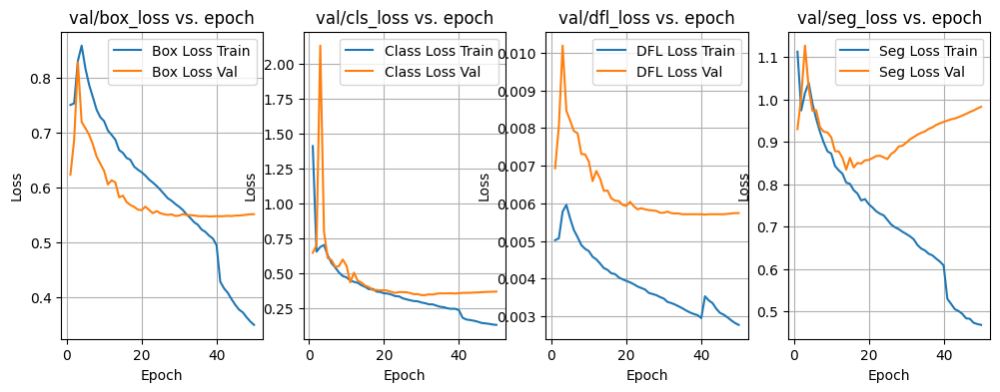

In [ ]:
# reusable function to plot the loss curves
def plot_loss_curve(metrics_df, metric, label, ax):
  ax.plot(metrics_df['epoch'], metrics_df[metric], label=label)
  ax.set_xlabel('Epoch')
  ax.set_ylabel('Loss')
  ax.set_title(metric + ' vs. epoch')
  ax.grid(True)
  ax.legend()

# plot the loss curves
_, ax = plt.subplots(1,4, figsize=(12, 4))
plot_loss_curve(metrics_df, 'train/box_loss', 'Box Loss Train', ax[0])
plot_loss_curve(metrics_df, 'val/box_loss', 'Box Loss Val', ax[0])
plot_loss_curve(metrics_df, 'train/cls_loss', 'Class Loss Train', ax[1])
plot_loss_curve(metrics_df, 'val/cls_loss', 'Class Loss Val', ax[1])
plot_loss_curve(metrics_df, 'train/dfl_loss', 'DFL Loss Train', ax[2])
plot_loss_curve(metrics_df, 'val/dfl_loss', 'DFL Loss Val', ax[2])
plot_loss_curve(metrics_df, 'train/seg_loss', 'Seg Loss Train', ax[3])
plot_loss_curve(metrics_df, 'val/seg_loss', 'Seg Loss Val', ax[3])
plt.show()

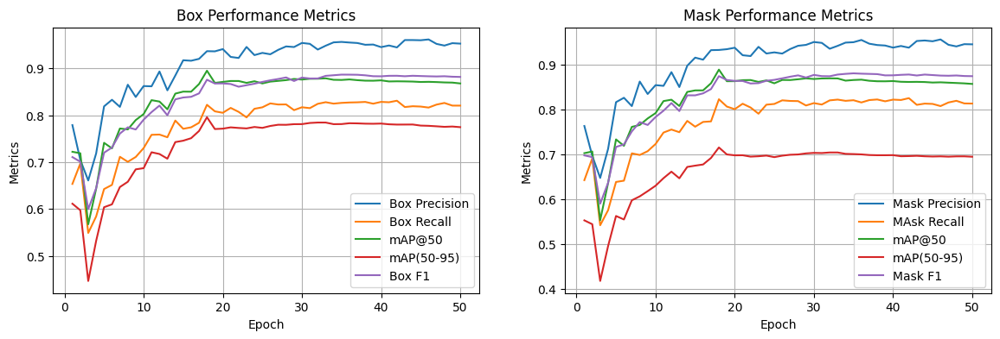

In [ ]:
# reusable function to plot performance metrics
def plot_metrics(metrics_df, metric, label, ax):
  ax.plot(metrics_df['epoch'], metrics_df[metric], label=label)
  ax.set_xlabel('Epoch')
  ax.set_ylabel('Metrics')
  ax.set_title(metric + ' vs. epoch')
  ax.grid(True)
  ax.legend()

# calculate box F1
metrics_df["f1B"] = 2*(metrics_df["metrics/precision(B)"]*metrics_df["metrics/recall(B)"]) / (metrics_df["metrics/precision(B)"]+metrics_df["metrics/recall(B)"])
# calculate mask F1
metrics_df["f1M"] = 2*(metrics_df["metrics/precision(M)"]*metrics_df["metrics/recall(M)"]) / (metrics_df["metrics/precision(M)"]+metrics_df["metrics/recall(M)"])

# plot the performance metrics
_, ax = plt.subplots(1,2, figsize=(14, 4))
plot_metrics(metrics_df, 'metrics/precision(B)', 'Box Precision', ax[0])
plot_metrics(metrics_df, 'metrics/recall(B)', 'Box Recall', ax[0])
plot_metrics(metrics_df, 'metrics/mAP50(B)', 'mAP@50', ax[0])
plot_metrics(metrics_df, 'metrics/mAP50-95(B)', 'mAP(50-95)', ax[0])
plot_metrics(metrics_df, 'f1B', 'Box F1', ax[0])
ax[0].set_title('Box Performance Metrics')
plot_metrics(metrics_df, 'metrics/precision(M)', 'Mask Precision', ax[1])
plot_metrics(metrics_df, 'metrics/recall(M)', 'MAsk Recall', ax[1])
plot_metrics(metrics_df, 'metrics/mAP50(M)', 'mAP@50', ax[1])
plot_metrics(metrics_df, 'metrics/mAP50-95(M)', 'mAP(50-95)', ax[1])
plot_metrics(metrics_df, 'f1M', 'Mask F1', ax[1])
ax[1].set_title('Mask Performance Metrics')
plt.show()

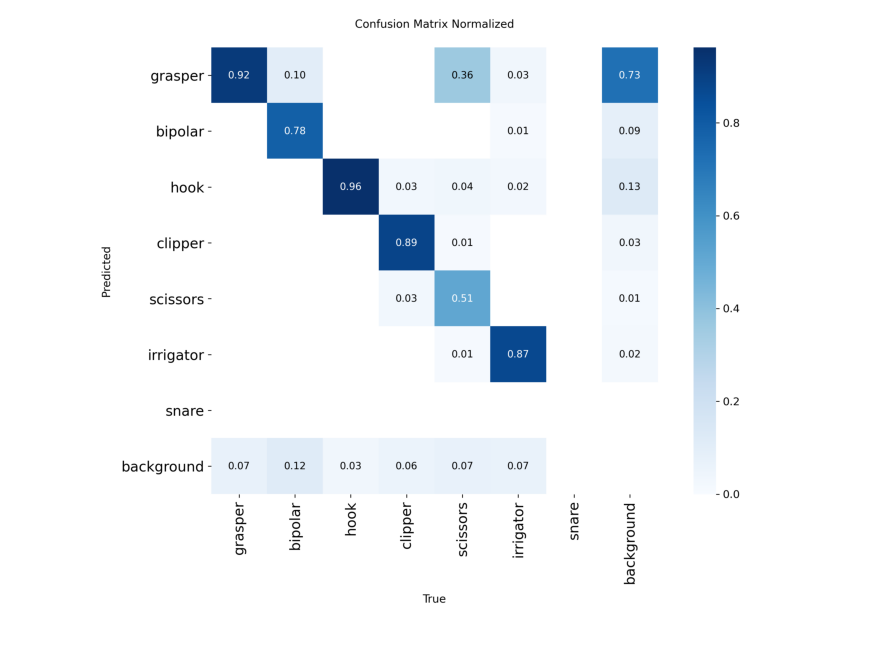

In [ ]:
# confusion matrix
cm = pltimg.imread('/content/drive/MyDrive/Surg_Data/yolo26_baseline/confusion_matrix_normalized.png')
plt.figure(figsize=(11, 11))
plt.imshow(cm)
plt.axis('off')
plt.show()

### 4.3.2 Make Predictions

In [ ]:
# load YOLO annotations from a .txt file
import random

# sample, predict, and display sample tests
# reusable function for YOLO26 model predictions
def sample_and_display_yolo_results(
    model,
    n=6,
    class_names=None,
    seed=42
):
    random.seed(seed)
    images_dir = Path(os.path.join(IMG_YOLO_ROOT, 'test'))
    labels_dir = Path(os.path.join(ANN_YOLO_ROOT, 'test'))
    image_files = list(images_dir.glob("*.png"))
    sample = random.sample(image_files, min(n, len(image_files)))

    for img_path in sample:
        # Load the sample
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Create the image with the real label for comparison
        label_path = labels_dir / (img_path.stem + ".txt")
        cls, boxes = load_yolo_labels(label_path)
        labeled_img = draw_yolo_masks(img.copy(), boxes, class_names)

        # Make the model prediction on the sample image
        print(f'Making model prediction for asset {img_path.stem}!')
        result = model(img_path)[0]
        pred_img = img.copy()
        names = []
        if result.masks is not None:
            names = [result.names[int(c)] for c in result.boxes.cls.cpu().numpy()]
            xyn = result.masks.xyn  # normalized mask polygon coordinates
            draw_yolo_masks(pred_img, xyn, class_names)

        cls = [result.names[int(c)] for c in cls]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,7))
        ax1.imshow(labeled_img)
        ax1.set_title(f'ACTUAL: {str(cls)}')
        ax1.axis("off")
        ax2.imshow(pred_img)
        ax2.set_title(f'PREDICTED: {str(names)}')
        ax2.axis("off")
        plt.tight_layout()
        plt.show()

Making model prediction for asset t80_VID58_002250!

image 1/1 /content/dataset/images/test/t80_VID58_002250.png: 384x640 1 hook, 19.8ms
Speed: 2.6ms preprocess, 19.8ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)


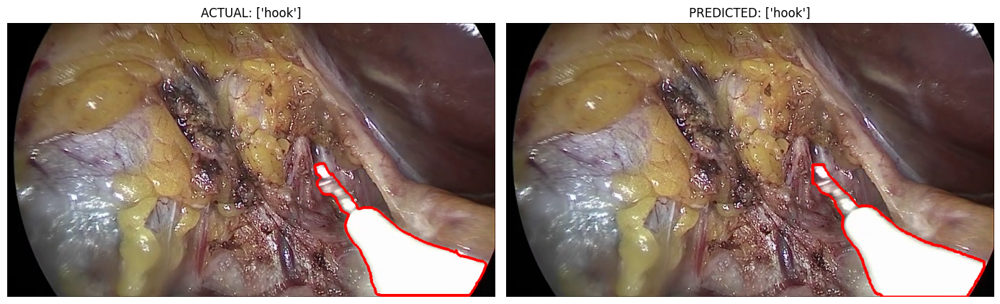

Making model prediction for asset seg8k_video09_001065!

image 1/1 /content/dataset/images/test/seg8k_video09_001065.png: 384x640 (no detections), 16.4ms
Speed: 2.0ms preprocess, 16.4ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)


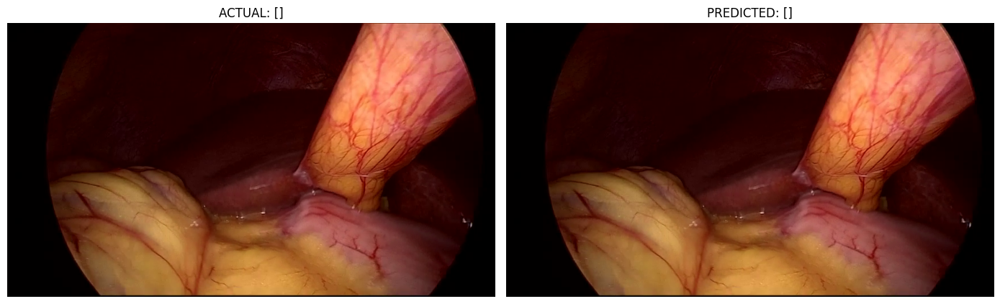

Making model prediction for asset seg8k_video24_000493!

image 1/1 /content/dataset/images/test/seg8k_video24_000493.png: 384x640 (no detections), 16.8ms
Speed: 2.1ms preprocess, 16.8ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)


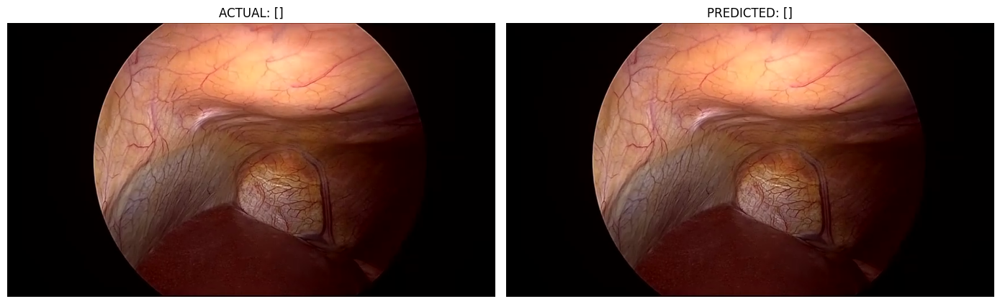

Making model prediction for asset t50_VID29_000817!

image 1/1 /content/dataset/images/test/t50_VID29_000817.png: 384x640 1 hook, 15.8ms
Speed: 1.9ms preprocess, 15.8ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)


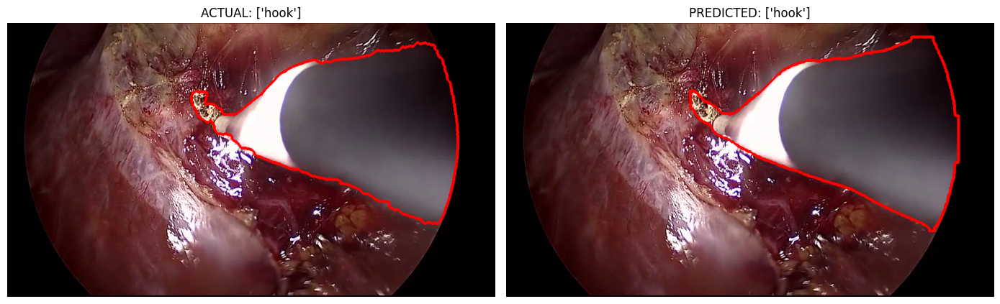

Making model prediction for asset t80_VID61_003540!

image 1/1 /content/dataset/images/test/t80_VID61_003540.png: 384x640 1 grasper, 15.6ms
Speed: 1.9ms preprocess, 15.6ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)


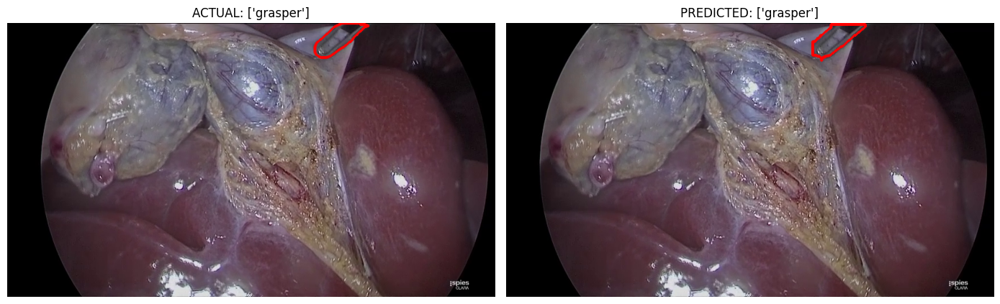

Making model prediction for asset t50_VID15_000987!

image 1/1 /content/dataset/images/test/t50_VID15_000987.png: 384x640 1 grasper, 1 hook, 16.4ms
Speed: 2.2ms preprocess, 16.4ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


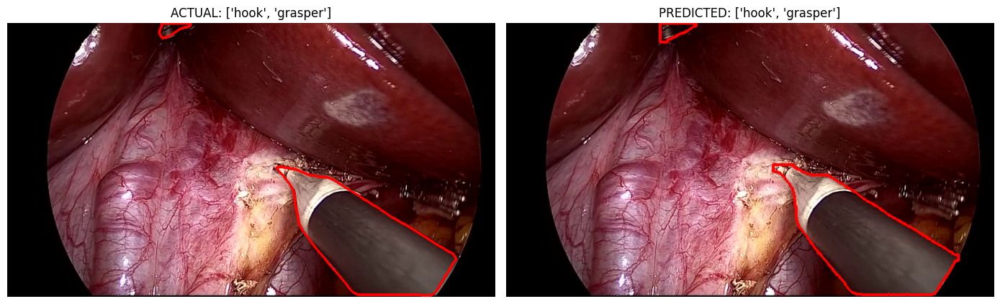

In [ ]:
# predict with the model
sample_and_display_yolo_results(model)

### 4.4 Model Analysis
> These results are reasonable overall, but I expected faster inference time than around 20ms in total, especially because training inference time was pretty fast: 1.4ms. The YOLO26-seg baseline model converged quickly around the 20th epoch, and reached strong, similar box and mask mAP@50 in the high 80's, with aproximately 95% precision and 83% recall, indicating that the model detects and segments instruments reliably. These results are supported by the test predictions. The class imbalance is evident in the confusion matrix, where rare instruments such as snare are never predicted, and scissors are correctly classified only 51% of the time, with 36% missclassified as grasper (the dominant instrument). Mask mAP50-95 is lower than the box mAP(50-95), which is not surprising given that the val seg_loss begins overfitting after 20th epoch, but still generalizes consistently overall. The other losses decrease smoothly and steadily.

> I believe the overall metrics, including the class imbalance can be improved through custom augmentations, a theory I will explore in the next section.

# 5.0 `Model 2: Fine-tuned YOLO26 with a Custom Augmentation Pipeline`
> The second model is YOLO26 fine-tuned with a custom augmentation pipeline, designed to address the mask-loss overfitting observed in the baseline model.

> Alabi et al. (2025) also make a strong case for using data augmentation techniques by presenting some challenging conditions, such as smoke, blur, dirty lens, reflection of instrument surface, tissue occlusion, etc., that can present real challenges for computer vision systems attempting to track and segment surgical instruments. The goal is to introduce additional variation during training to improve generalization across diverse surgical conditions and frames.

> For this purpose, I will use the [Albumentations library](https://docs.ultralytics.com/guides/yolo-data-augmentation), which fully integrates with Ultralytics YOLO26 to read and transform both the images and the polygon coordinates simultaneously.

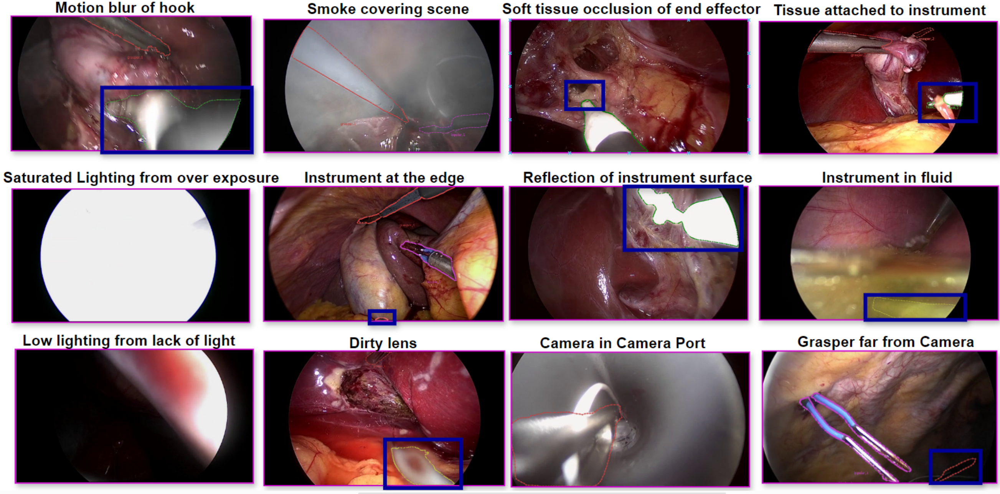
 Figure 3. CholecInstanceSeg: Hard Cases (Alabi et al., 2025)




### 5.1 Custom Data Augmentation Pipeline

In [ ]:
# custom data augmentation pipeline
import albumentations as A
TARGET_SIZE = 640

augmentations = [

   # sharpening and contrast augments, valuable for hard cases
    A.OneOf([
        A.CLAHE(clip_limit=2.5, tile_grid_size=(8, 8), p=1.0),
        A.UnsharpMask(blur_limit=(3, 7), p=1.0),
        A.AutoContrast(p=1.0),
    ], p=0.7),


    # color and lighting augments
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.8),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.8),
        A.RandomGamma(gamma_limit=(80, 120), p=0.3),
    ], p=0.7),

    # blur; common in laparoscopic images
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 7), p=0.8),
        A.MedianBlur(blur_limit=5, p=0.8),
        A.MotionBlur(blur_limit=(3, 7), p=0.8),
    ], p=0.5),

    # augments to target surgical cases such as smoke, lens occlusion
     A.OneOf([
        A.RandomFog(fog_coef_range=(0.1, 0.4), p=1.0),
        A.Spatter(p=1.0),
    ], p=0.4),

    # noise; trains for noise resistance
    A.OneOf([
        A.GaussNoise(std_range=(0.05, 0.20), p=1.0),
        A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5), p=1.0),
        A.MultiplicativeNoise(multiplier=(0.9, 1.1), per_channel=True, p=1.0),
    ], p=0.3),

    # compression artifacts since my images are video extracted
    A.OneOf([
        A.ImageCompression(quality_range=(50, 90), p=0.7),
        A.Downscale(scale_range=(0.6, 0.8), p=0.7),
    ], p=0.2),
]


> `Note`: I have been having issues with the geometric/affine augmentations (rotation, scaling, translation, perspective warping), and applying them directly into the model seemed to fix the error. To address class imbalance, I increased the classification loss weight (cls=1.5) to penalize misclassifications more heavily, encouraging the model to pay greater attention to underrepresented classes. Techniques such as mosaic, copy-paste, and mixup were added to synthetically increase the presence of rare instrument instances by compositing and blending them across multiple training images, effectively exposing the model to a more balanced class distribution.

### 5.2 Training

In [ ]:
# load a COCO-pretrained YOLO26n model
model = YOLO('yolo26m-seg.pt')
# train the model on the CholecInstanceSeg
results_yolo_augmented = model.train(
    data=os.path.join(YOLO_ROOT, 'data.yaml'),
    epochs=50,
    imgsz=640,
    batch=16,
    cls=1.5,
    mosaic=0.8,
    copy_paste=0.3,
    mixup=0.1,
    degrees=30,
    scale=0.2,
    translate=0.1,
    perspective=0.001,
    augmentations=augmentations,
    project='/content/drive/MyDrive/Surg_Data',
    name='yolo26_augmented'
)

Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, augmentations=[OneOf([
  CLAHE(p=1.0, clip_limit=(1.0, 2.5), tile_grid_size=(8, 8)),
  UnsharpMask(p=1.0, alpha=(0.2, 0.5), blur_limit=(3, 7), sigma_limit=(0.0, 0.0), threshold=10),
  AutoContrast(p=1.0, cutoff=0.0, ignore=None, method='cdf'),
], p=0.7), OneOf([
  RandomBrightnessContrast(p=0.8, brightness_by_max=True, brightness_limit=(-0.2, 0.2), contrast_limit=(-0.2, 0.2), ensure_safe_range=False),
  ColorJitter(p=0.8, brightness=(0.8, 1.2), contrast=(0.8, 1.2), hue=(-0.1, 0.1), saturation=(0.8, 1.2)),
  RandomGamma(p=0.3, gamma_limit=(80.0, 120.0)),
], p=0.7), OneOf([
  GaussianBlur(p=0.8, blur_limit=(3, 7), sigma_limit=(0.5, 3.0)),
  MedianBlur(p=0.8, blur_limit=(3, 5)),
  MotionBlur(p=0.8, allow_shifted=True, angle_range=(0.0, 360.0), blur_limit=(3, 7), direction_range=(-1.0, 1.0)),
], p=0.5), OneOf([
  RandomFog(p

/usr/local/lib/python3.12/dist-packages/ultralytics/data/augment.py:1183: RuntimeWarning: divide by zero encountered in divide
  xy = xy[:, :2] / xy[:, 2:3]


      37/50      11.7G     0.7599     0.9953      1.531   0.005299     0.1687         56        640: 100% ━━━━━━━━━━━━ 1677/1677 1.5it/s 19:03
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 134/134 3.4it/s 39.0s
                   all       4284       6713      0.948      0.864      0.921      0.822      0.944      0.861      0.914      0.748

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
      38/50      11.7G     0.7429     0.9724      1.497   0.005201     0.1628         72        640: 100% ━━━━━━━━━━━━ 1677/1677 1.5it/s 18:26
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 134/134 3.7it/s 36.2s
                   all       4284       6713       0.96      0.856       0.92      0.821      0.953      0.852      0.913      0.747

### 5.3 Evaluation

In [ ]:
# load the last checkpoint
model = YOLO('/content/drive/MyDrive/Surg_Data/yolo26_augmented/weights/last.pt')

# load the baseline training log data
metrics_df = pd.read_csv("/content/drive/MyDrive/Surg_Data/yolo26_augmented/results.csv")
metrics_df.head()

,epoch,time,train/box_loss,train/seg_loss,train/cls_loss,train/dfl_loss,train/sem_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),...,val/dfl_loss,val/sem_loss,lr/pg0,lr/pg1,lr/pg2,lr/pg3,lr/pg4,lr/pg5,lr/pg6,lr/pg7
0,1,1263.03,1.00028,1.61370,5.29824,0.00796,1.05713,0.83857,0.59341,0.68322,...,0.00731,0,0.009994,0.003331,0.009994,0.003331,0.009994,0.003331,0.009994,0.003331
1,2,2487.96,0.99145,1.43864,3.24428,0.00776,0.44171,0.87804,0.63707,0.74668,...,0.00780,0,0.019598,0.006533,0.019598,0.006533,0.019598,0.006533,0.019598,0.006533
2,3,3693.96,1.06855,1.50136,3.35080,0.00849,0.45892,0.75587,0.60216,0.69150,...,0.00920,0,0.028806,0.009602,0.028806,0.009602,0.028806,0.009602,0.028806,0.009602
3,4,4820.96,1.10899,1.52364,3.36370,0.00885,0.45514,0.80033,0.72339,0.78339,...,0.00910,0,0.028218,0.009406,0.028218,0.009406,0.028218,0.009406,0.028218,0.009406
4,5,6055.41,1.07934,1.46725,3.09874,0.00850,0.41252,0.84270,0.74891,0.83452,...,0.00898,0,0.027624,0.009208,0.027624,0.009208,0.027624,0.009208,0.027624,0.009208


### 5.3.1 Loss Functions and Performance Metrics

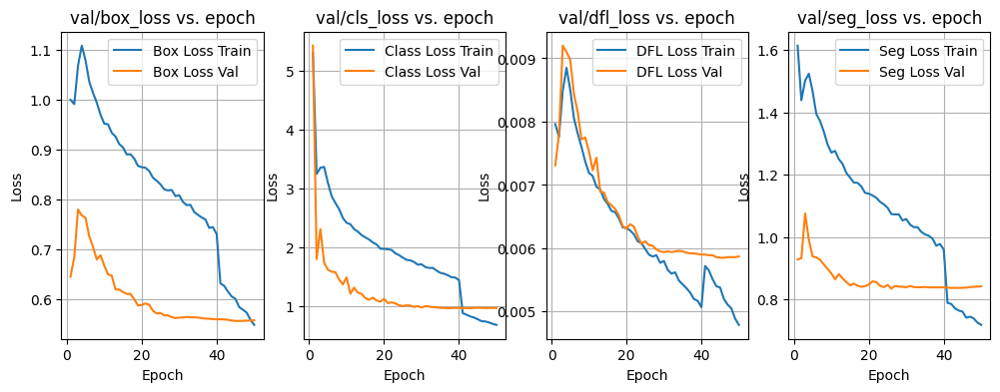

In [ ]:
def plot_loss_curve(metrics_df, metric, label, ax):
  ax.plot(metrics_df['epoch'], metrics_df[metric], label=label)
  ax.set_xlabel('Epoch')
  ax.set_ylabel('Loss')
  ax.set_title(metric + ' vs. epoch')
  ax.grid(True)
  ax.legend()

# Plot the loss curves
_, ax = plt.subplots(1,4, figsize=(12, 4))
plot_loss_curve(metrics_df, 'train/box_loss', 'Box Loss Train', ax[0])
plot_loss_curve(metrics_df, 'val/box_loss', 'Box Loss Val', ax[0])
plot_loss_curve(metrics_df, 'train/cls_loss', 'Class Loss Train', ax[1])
plot_loss_curve(metrics_df, 'val/cls_loss', 'Class Loss Val', ax[1])
plot_loss_curve(metrics_df, 'train/dfl_loss', 'DFL Loss Train', ax[2])
plot_loss_curve(metrics_df, 'val/dfl_loss', 'DFL Loss Val', ax[2])
plot_loss_curve(metrics_df, 'train/seg_loss', 'Seg Loss Train', ax[3])
plot_loss_curve(metrics_df, 'val/seg_loss', 'Seg Loss Val', ax[3])
plt.show()

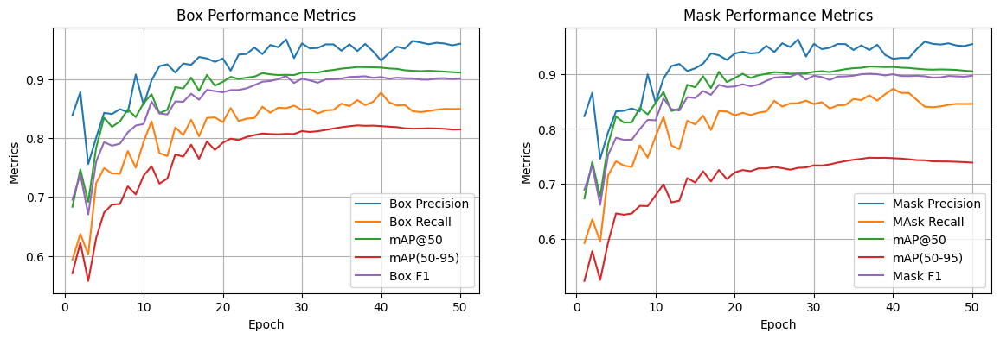

In [ ]:
def plot_metrics(metrics_df, metric, label, ax):
  ax.plot(metrics_df['epoch'], metrics_df[metric], label=label)
  ax.set_xlabel('Epoch')
  ax.set_ylabel('Metrics')
  ax.set_title(metric + ' vs. epoch')
  ax.grid(True)
  ax.legend()

# calculate box F1
metrics_df["f1B"] = 2*(metrics_df["metrics/precision(B)"]*metrics_df["metrics/recall(B)"]) / (metrics_df["metrics/precision(B)"]+metrics_df["metrics/recall(B)"])
# calculate mask F1
metrics_df["f1M"] = 2*(metrics_df["metrics/precision(M)"]*metrics_df["metrics/recall(M)"]) / (metrics_df["metrics/precision(M)"]+metrics_df["metrics/recall(M)"])

# Plot the loss curves
_, ax = plt.subplots(1,2, figsize=(14, 4))
plot_metrics(metrics_df, 'metrics/precision(B)', 'Box Precision', ax[0])
plot_metrics(metrics_df, 'metrics/recall(B)', 'Box Recall', ax[0])
plot_metrics(metrics_df, 'metrics/mAP50(B)', 'mAP@50', ax[0])
plot_metrics(metrics_df, 'metrics/mAP50-95(B)', 'mAP(50-95)', ax[0])
plot_metrics(metrics_df, 'f1B', 'Box F1', ax[0])
ax[0].set_title('Box Performance Metrics')
plot_metrics(metrics_df, 'metrics/precision(M)', 'Mask Precision', ax[1])
plot_metrics(metrics_df, 'metrics/recall(M)', 'MAsk Recall', ax[1])
plot_metrics(metrics_df, 'metrics/mAP50(M)', 'mAP@50', ax[1])
plot_metrics(metrics_df, 'metrics/mAP50-95(M)', 'mAP(50-95)', ax[1])
plot_metrics(metrics_df, 'f1M', 'Mask F1', ax[1])
ax[1].set_title('Mask Performance Metrics')
plt.show()

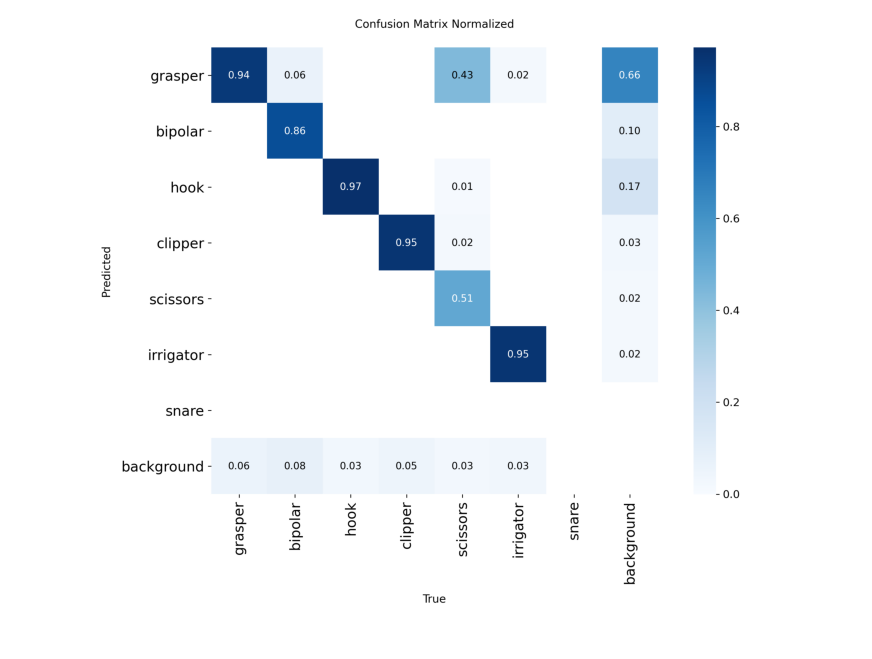

In [ ]:
cm = pltimg.imread('/content/drive/MyDrive/Surg_Data/yolo26_augmented/confusion_matrix_normalized.png')
plt.figure(figsize=(11, 11))
plt.imshow(cm)
plt.axis('off')
plt.show()

### 5.3.3 Make Predictions

Making model prediction for asset t80_VID38_000150!

image 1/1 /content/dataset/images/test/t80_VID38_000150.png: 384x640 1 grasper, 1 hook, 100.5ms
Speed: 9.0ms preprocess, 100.5ms inference, 61.0ms postprocess per image at shape (1, 3, 384, 640)


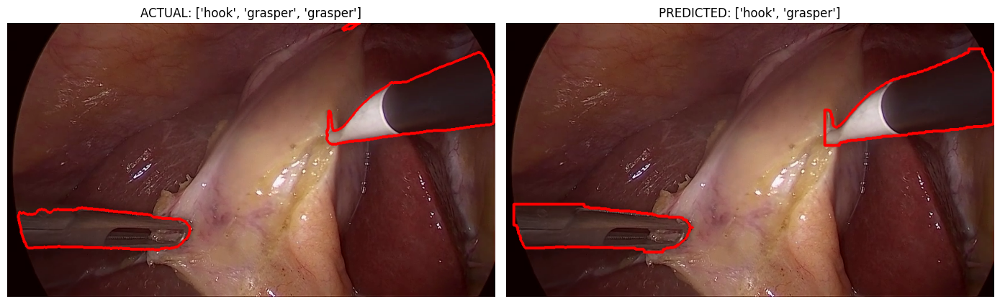

Making model prediction for asset t50_VID29_001491!

image 1/1 /content/dataset/images/test/t50_VID29_001491.png: 384x640 1 grasper, 1 hook, 16.8ms
Speed: 1.9ms preprocess, 16.8ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


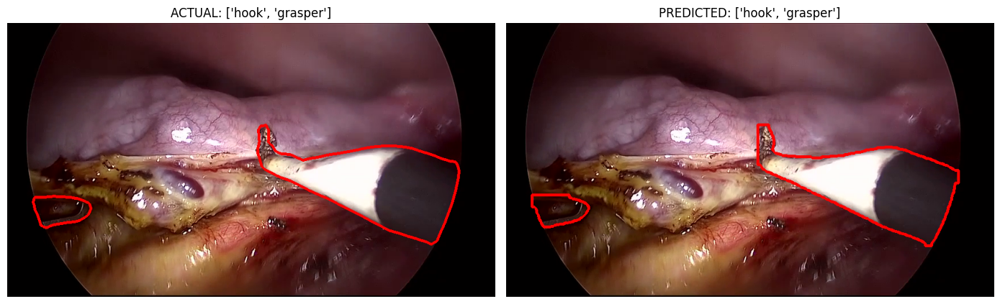

Making model prediction for asset t50_VID29_000222!

image 1/1 /content/dataset/images/test/t50_VID29_000222.png: 384x640 1 grasper, 1 hook, 16.6ms
Speed: 1.9ms preprocess, 16.6ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


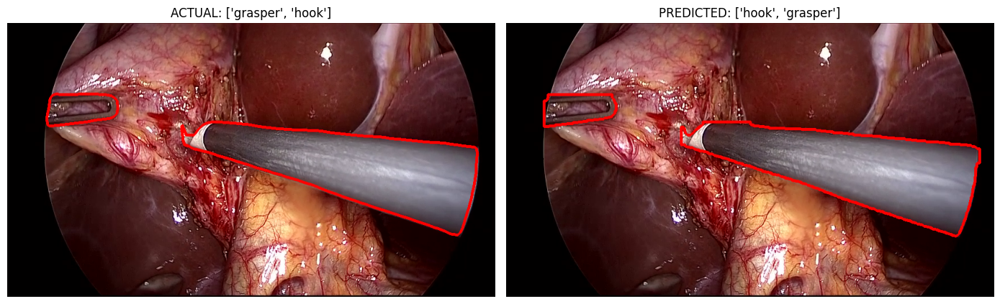

Making model prediction for asset t50_VID14_000158!

image 1/1 /content/dataset/images/test/t50_VID14_000158.png: 384x640 1 grasper, 1 hook, 15.9ms
Speed: 2.0ms preprocess, 15.9ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


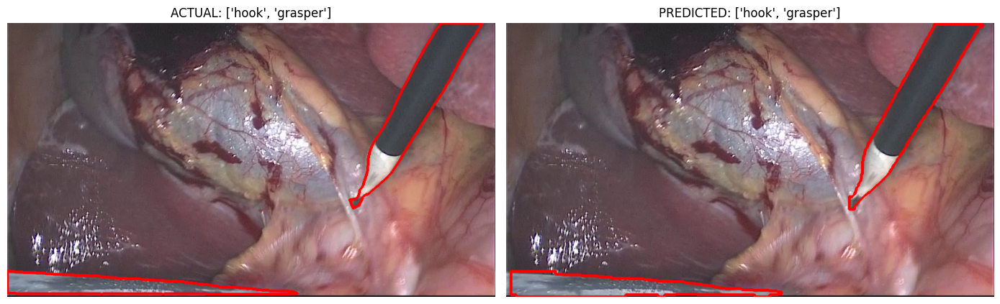

Making model prediction for asset seg8k_video09_000845!

image 1/1 /content/dataset/images/test/seg8k_video09_000845.png: 384x640 (no detections), 17.4ms
Speed: 2.9ms preprocess, 17.4ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)


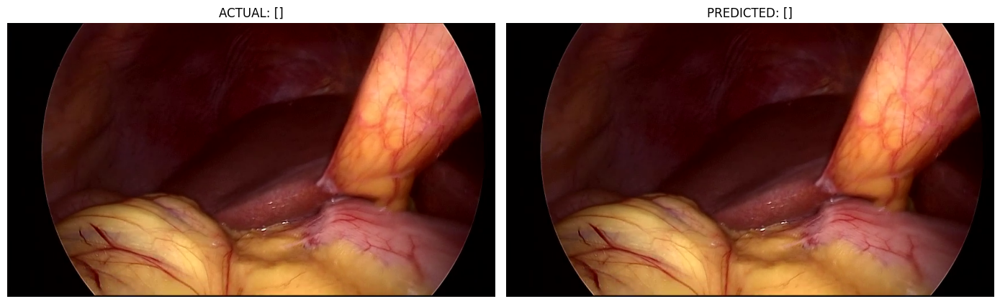

Making model prediction for asset t50_VID22_000995!

image 1/1 /content/dataset/images/test/t50_VID22_000995.png: 384x640 2 graspers, 1 hook, 16.1ms
Speed: 1.9ms preprocess, 16.1ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


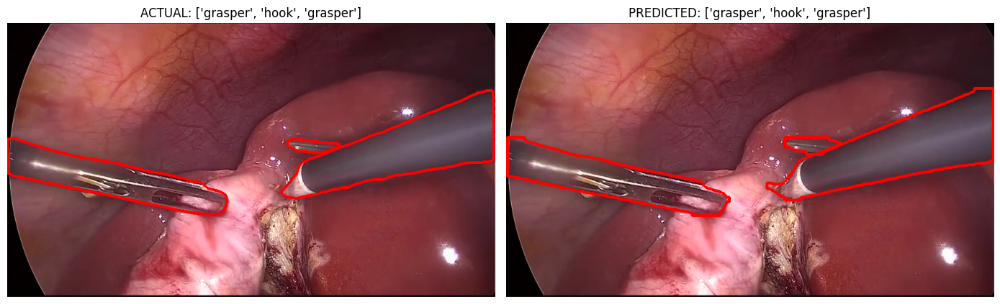

In [ ]:
# Predict with the model
sample_and_display_yolo_results(model)

### 5.4 Model Analysis
> The augmentation techniques and changes to the loss function worked as expected. The mask loss is not overfitting anymore and is converging nicely. The Box, CLS and DFL loss are marginally higher than the baseline model, which is likely a trade-off of changes to the loss function and augmentations. The overall mAP and per-class mAP have also improved across every single class. Looking at the confusion matrix, the grasper still accounts for the majority of the false-positive predictions, although with a 7% reduction from the previous model. There is also a reduction in missed instances across every class.

> Overall, the augmented model is superior to the baseline YOLO26 model.

# `6.0 Model 3: Fine-tuned SAM2`
Segment Anything Model 2 (SAM2) is a tool designed by Meta for comprehensive object segmentation in both images and videos. For the purpose of this project it was fine-tuned on the CholeInstanceSeg dataset as suggested by the Meta team [here](https://github.com/facebookresearch/sam2/blob/main/README.md). Couple of things to note:

1. The reason I did not use the one that is proposed by [Ultralytics](https://docs.ultralytics.com/models/sam-2) is that theirs is not trainable and is intended to be used as a black box model.

2. The most challenging part of fine-tuning SAM2 was making changes to the configuration file .yaml. The only documentation provided by Meta is a single sample file, which was missing a lot of features I needed. The values in the .yaml file map directly to Python class parameters, so in order to figure out how to add new features to the config, I had to reference the class definitions in SAM2's codebase. Additionally, SAM2 is oriented around video frames rather than single images, so I had to figure out for myself how to use and configure the PNGRawDataset for palette images, since the provided SAM2 sample config is set up for video encoding. Since these features are not documented, it was quite challenging to find and configure the SAM2 training with all of the features and settings that I required.

To prepare for model training, after an extensive trial-and-error process, I made the following changes to the configuration file:

   * file path management
   * downgraded image resolution from 1024 to 512
   * increased train_batch_size to 16
   * decreased the number of frames to 1
   * decreased the length of training from 40 to 10 epochs
   * added validation during training
   * froze the image encoder
   * enabled palette-mode handling for the PNG masks, so they are read correctly as segmentation labels.
     


### 6.1 Training

In [9]:
# clone sam2
%cd /content
!git clone https://github.com/facebookresearch/sam2.git

/content
Cloning into 'sam2'...
remote: Enumerating objects: 1096, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 1096 (delta 1), reused 0 (delta 0), pack-reused 1094 (from 2)
Receiving objects: 100% (1096/1096), 134.84 MiB | 33.42 MiB/s, done.
Resolving deltas: 100% (376/376), done.


In [ ]:
# upload the config file that has been pre-configured offline
drive_path = '/content/drive/MyDrive/Surg_Data'
shutil.copy(os.path.join(drive_path, 'sam2_config.yaml'), 'sam2/sam2/configs/sam2_config.yaml')

'sam2/sam2/configs/sam2_config.yaml'

In [10]:
# install sam2 packages
# it's important to be in this dir to import SAM2 this way
%cd /content/sam2
!pip install -e .[dev] -q


/content/sam2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.8/536.8 kB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 108.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 7.4 

In [11]:
# load sam2 base model checkpoint into sam2's checkpoint folder
# code borrowed from ./sam2/download_ckpts.sh
%cd /content/sam2/checkpoints
SAM2p1_BASE_URL="https://dl.fbaipublicfiles.com/segment_anything_2/092824"
sam2p1_hiera_b_plus_url=f'{SAM2p1_BASE_URL}/sam2.1_hiera_base_plus.pt'

print('Downloading sam2.1_hiera_base_plus.pt checkpoint...')
!wget $sam2p1_hiera_b_plus_url

# cd up to sam2 folder
%cd ..

/content/sam2/checkpoints
--2026-05-13 03:02:13--  https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_base_plus.pt
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 18.239.50.104, 18.239.50.120, 18.239.50.9, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|18.239.50.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 323606802 (309M) [application/vnd.snesdev-page-table]
Saving to: ‘sam2.1_hiera_base_plus.pt’

sam2.1_hiera_base_p 100%[===================>] 308.62M   356MB/s    in 0.9s    

2026-05-13 03:02:14 (356 MB/s) - ‘sam2.1_hiera_base_plus.pt’ saved [323606802/323606802]

/content/sam2


### Model Training

In [ ]:
%cd /content/sam2

# Run sam2 training
!python ./training/train.py -c 'configs/sam2_config.yaml' --use-cluster 0 --num-gpus 1

%cd ..

Streaming output truncated to the last 5000 lines.
INFO 2026-05-04 03:18:08,782 train_utils.py: 271: Train Epoch: [3][2000/3036] | Batch Time: 0.37 (0.36) | Data Time: 0.00 (0.02) | Mem (GB): 7.00 (7.82/11.00) | Time Elapsed: 00d 01h 16m | Losses/train_all_loss: 1.02e+00 (1.22e+00) | Losses/train_val_all_loss: 0.00e+00 (0.00e+00)
INFO 2026-05-04 03:23:53,322 train_utils.py: 271: Train Epoch: [3][3000/3036] | Batch Time: 0.34 (0.36) | Data Time: 0.00 (0.01) | Mem (GB): 8.00 (7.83/11.00) | Time Elapsed: 00d 01h 21m | Losses/train_all_loss: 8.75e-01 (1.21e+00) | Losses/train_val_all_loss: 0.00e+00 (0.00e+00)
INFO 2026-05-04 03:24:05,777 trainer.py: 950: Estimated time remaining: 00d 02h 11m
INFO 2026-05-04 03:24:05,780 trainer.py: 892: Synchronizing meters
INFO 2026-05-04 03:24:05,780 trainer.py: 830: Losses and meters: {'Losses/train_all_loss': 1.2130235075872091, 'Losses/train_val_all_loss': 0, 'Losses/train_all_loss_mask': 0.014497484513944964, 'Losses/train_all_loss_dice': 0.657647971

In [ ]:
# upload train and val loss results and combine in a data frame
train = pd.read_json('/content/drive/MyDrive/Surg_Data/sam2/logs/logs/train_stats.json', lines=True)
val = pd.read_json('/content/drive/MyDrive/Surg_Data/sam2/logs/logs/val_stats.json', lines=True)
metrics_df = train.merge(val, on="Trainer/epoch", how="outer", suffixes=("_train", "_val"))
# visualize df
metrics_df.head()

,Losses/train_all_loss,Losses/train_val_all_loss,Losses/train_all_loss_mask,Losses/train_all_loss_dice,Losses/train_all_loss_iou,Losses/train_all_loss_class,Losses/train_all_core_loss,Trainer/where_train,Trainer/epoch,Trainer/steps_train,Losses/val_all_loss,Losses/val_val_all_loss,Losses/val_val_all_loss_mask,Losses/val_val_all_loss_dice,Losses/val_val_all_loss_iou,Losses/val_val_all_loss_class,Losses/val_val_all_core_loss,Trainer/where_val,Trainer/steps_val
0,1.425339,0,0.017634,0.756466,0.316187,6.126297e-08,1.425339,0.099967,0,3036,0,1.104839,0.011149,0.619446,0.262413,9.051921e-09,1.104839,0.099967,233
1,1.269414,0,0.015312,0.685445,0.277723,1.663092e-08,1.269414,0.199967,1,6072,0,1.064323,0.010540,0.597959,0.255557,7.633271e-09,1.064323,0.199967,466
2,1.235595,0,0.014834,0.668441,0.270467,1.764939e-08,1.235595,0.299967,2,9108,0,1.039502,0.010387,0.586525,0.245231,7.483683e-09,1.039502,0.299967,699
3,1.213024,0,0.014497,0.657648,0.265426,1.875536e-08,1.213024,0.399967,3,12144,0,1.025065,0.010313,0.576626,0.242170,1.288103e-08,1.025065,0.399967,932
4,1.188784,0,0.014193,0.645734,0.259187,1.820041e-08,1.188784,0.499967,4,15180,0,1.017978,0.010063,0.575050,0.241667,9.009680e-09,1.017978,0.499967,1165


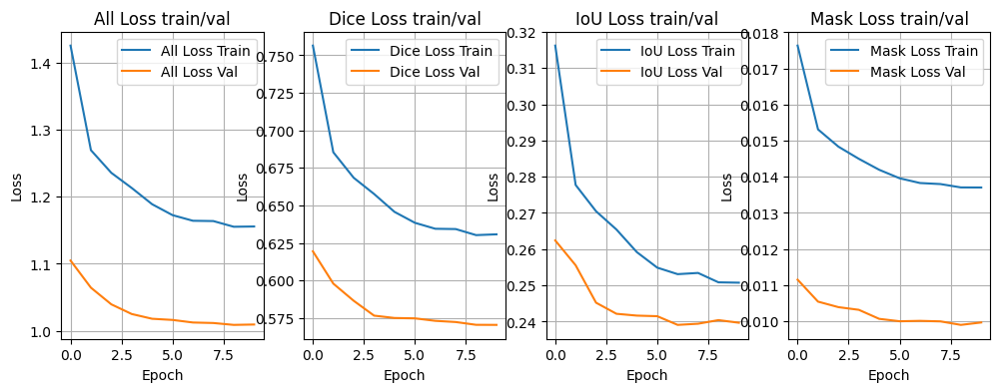

In [ ]:
def plot_loss_curve(metrics_df, metric, label, ax):
  ax.plot(metrics_df['Trainer/epoch'], metrics_df[metric], label=label)
  ax.set_xlabel('Epoch')
  ax.set_ylabel('Loss')
  # ax.set_title(metric + ' vs. epoch')
  ax.grid(True)
  ax.legend()

# Plot the loss curves
_, ax = plt.subplots(1,4, figsize=(12, 4))
plot_loss_curve(metrics_df, 'Losses/train_all_loss', 'All Loss Train', ax[0])
plot_loss_curve(metrics_df, 'Losses/val_val_all_loss', 'All Loss Val', ax[0])
ax[0].set_title('All Loss train/val')
plot_loss_curve(metrics_df, 'Losses/train_all_loss_dice', 'Dice Loss Train', ax[1])
plot_loss_curve(metrics_df, 'Losses/val_val_all_loss_dice', 'Dice Loss Val', ax[1])
ax[1].set_title('Dice Loss train/val')
plot_loss_curve(metrics_df, 'Losses/train_all_loss_iou', 'IoU Loss Train', ax[2])
plot_loss_curve(metrics_df, 'Losses/val_val_all_loss_iou', 'IoU Loss Val', ax[2])
ax[2].set_title('IoU Loss train/val')
plot_loss_curve(metrics_df, 'Losses/train_all_loss_mask', 'Mask Loss Train', ax[3])
plot_loss_curve(metrics_df, 'Losses/val_val_all_loss_mask', 'Mask Loss Val', ax[3])
ax[3].set_title('Mask Loss train/val')
plt.show()

> There is clear evidence that the model is learning. Total loss, Dice, IoU and Mask loss all decrease fairly smooth and steady before converging around the 7th epoch, without any signs of overfitting.

In [12]:
# SAM2 library imports for model predictions
from sam2 import build_sam
from sam2.sam2_image_predictor import SAM2ImagePredictor

In [13]:
# create path for merged checkpoints
SAM2_COMBINED = '/content/drive/MyDrive/Surg_Data/sam2/checkpoints/sam2.1_finetuned_merged.pt'

# merge the base checkpoint with our tuned weights (my checkpoint is not a complete model)
base = torch.load('./checkpoints/sam2.1_hiera_base_plus.pt', map_location='cpu', weights_only=True)
checkpoint = torch.load('/content/drive/MyDrive/Surg_Data/sam2/checkpoints/checkpoint.pt', map_location='cpu', weights_only=True)

# save the full model to drive
merged = base['model'].copy()
merged.update(checkpoint['model'])
torch.save({'model': merged}, SAM2_COMBINED)

In [14]:
# create the sam2 predictor
model = build_sam.build_sam2(
    config_file='configs/sam2.1/sam2.1_hiera_b+.yaml',
    ckpt_path=SAM2_COMBINED,
    device='cuda',
)
predictor = SAM2ImagePredictor(model)

In [17]:
# create yolo model
yolo_model = YOLO('/content/drive/MyDrive/Surg_Data/yolo26_augmented/weights/last.pt')

In [18]:
# turn a mask (np array image) into a bounding box for the given palette color
def mask_to_box(mask, color):
    ys, xs = np.where(mask == color)
    if len(xs) == 0:
        return None
    return np.array([xs.min(), ys.min(), xs.max(), ys.max()])

# save the given image (nparray) to the given path (this will add /1.png internally!)
def save_pred(path, name, image):
    result_img = Image.fromarray(image)
    result_img = result_img.convert('P')
    out_dir = os.path.join(path, name)
    os.makedirs(out_dir, exist_ok=True)
    result_img.save(os.path.join(out_dir, '1.png'))

# merge a new_img mask into the predicted_img palette
def add_obj_to_palette(predicted_img, new_img, color):
    new_img = np.asarray(new_img) * color
    comb_mask = new_img > 0
    predicted_img[comb_mask] = new_img[comb_mask]

#### The next block of code is where the actual predictions are happening on every image from test data, for each of the 3 models: SAM2, yolo_augmented, and yolo_augmented + SAM2.

For each image in test data:
> * makes yolo predictions
> * makes sam2 predictions (standalone: using labels to get bounding box as prompt)
> * makes sam2+yolo combined predictions (yolo prediction gives bounding box as prompt)

All results are saved as palette PNGs, which is how SAM2's `sav_evaluator` will measure the results.


In [28]:
import time
# make the predictions on test manually
#      # loop through each test image
label_dir = '/content/dataset/sam2labels/test'
test_dir = Path('/content/dataset/sam2images/test')

sam2_pred_dir = '/content/dataset/sam2preds/test'
yolo_pred_dir = '/content/dataset/yolopreds/test'
comb_pred_dir = '/content/dataset/combpreds/test'

test_imgs = list(test_dir.glob("*.png"))
sam_time = []
sam_conf = []
yolo_time = []
yolo_conf = []
comb_time = []
comb_conf = []

print(f'Making predictions on {len(test_imgs)} test images..')

for img_dir in test_imgs:
    # load original image
    img = os.path.join(img_dir, '1.jpg')
    image = np.array(Image.open(img))
    height, width, _ = image.shape
    base_img = np.zeros((height, width), dtype=np.uint8)

    # load label (skip any that don't exist (no objects))
    label = os.path.join(label_dir, img_dir.name, '1.png')
    gt_mask = base_img.copy()
    if os.path.exists(label):
        gt_img = Image.open(label)
        gt_mask = np.array(gt_img)
    else:
      # if label doesn't exist, we can't make a prediction with SAM standalone.
      # fall back to an empty image
      gt_mask = base_img.copy()
      gt_img = Image.fromarray(gt_mask)
    mask_colors = [i[1] for i in gt_img.getcolors()]
    label_obj_count = len(mask_colors) - 1

    # make the YOLO prediction
    start_time = time.perf_counter()
    result = yolo_model(img, verbose=False)[0]
    end_time = time.perf_counter()
    current_yolo_time = end_time - start_time

    yolo_pred = base_img.copy()
    count = 0
    boxes = result.boxes.cpu()
    if result.masks is not None:
      count = result.masks.cpu().shape[0]
      for i in range(min(count, label_obj_count)):
          mask = result.masks.data[i].cpu().numpy()
          img = Image.fromarray(mask)
          img = img.resize((width, height))
          color = i + 1

          add_obj_to_palette(yolo_pred, img, i + 1)
          yolo_time.append(end_time - start_time)
     # save prediction into sam2preds directory
    save_pred(yolo_pred_dir, img_dir.name, yolo_pred)

    # make the sam2 standalone prediction (based on label)
    predictor.set_image(image)
    sam_pred = base_img.copy()
    for color in mask_colors:
        # skip 0 (background)
        if (color < 1): continue
        # create bounding box for this color
        box = mask_to_box(gt_mask, color)

        # make sam2 prediction (and measure runtime)
        start_time = time.perf_counter()
        masks, iou_preds, _ = predictor.predict(
            box=box,
            multimask_output=True,
        )
        end_time = time.perf_counter()
        sam_time.append(end_time - start_time)
        # layer predicted mask onto output image
        best_idx = iou_preds.argmax()
        add_obj_to_palette(sam_pred, masks[best_idx], color)
        sam_conf.append(iou_preds[best_idx])
    # save prediction into sam2preds directory
    save_pred(sam2_pred_dir, img_dir.name, sam_pred)

    # make the combined prediction
    predictor.set_image(image)
    comb_pred = base_img.copy()
    for i, result_box in enumerate(boxes):
        if i >= label_obj_count: break
        # get bounding box from YOLO prediction for this color
        box = result_box.xyxy
        conf = result_box.conf.numpy()[0]
        # make sam2 prediction (and measure runtime)
        start_time = time.perf_counter()
        masks, iou_preds, _ = predictor.predict(
            box=box,
            multimask_output=True,
        )
        end_time = time.perf_counter()
        comb_time.append(current_yolo_time + end_time - start_time)
        # layer predicted mask onto output image
        best_idx = iou_preds.argmax()
        add_obj_to_palette(comb_pred, masks[best_idx], i + 1)

        yolo_conf.append(conf)
        comb_conf.append(iou_preds[best_idx])
    # save prediction into sam2preds directory
    save_pred(comb_pred_dir, img_dir.name, comb_pred)

    # add to stats for any real object not detected by YOLO
    missed = label_obj_count - count
    for i in range(missed):
        yolo_conf.append(0)
        yolo_time.append(0)
        comb_conf.append(0)
        comb_time.append(0)

print('Finished all predictions on test set!')


Making predictions on 10819 test images..
Finished all predictions on test set!


In [ ]:
print(f'Yolo data recorded {len(yolo_conf)} events')

Yolo data recorded 16162 events


In [22]:
# install requirements for SAM2 evaluator
%cd /content/sam2/sav_dataset
!pip install -r requirements.txt


/content/sam2/sav_dataset
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 24.4 MB/s eta 0:00:00


In [1]:
# run Meta's evaluator against each dataset
# yolo
!python sav_evaluator.py --gt_root /content/dataset/sam2labels/test --pred_root /content/dataset/yolopreds/test --do_not_skip_first_and_last_frame

# sam standalone
!python sav_evaluator.py --gt_root /content/dataset/sam2labels/test --pred_root /content/dataset/sam2preds/test --do_not_skip_first_and_last_frame

# sam+yolo
!python sav_evaluator.py --gt_root /content/dataset/sam2labels/test --pred_root /content/dataset/combpreds/test --do_not_skip_first_and_last_frame

### Results for SAM2

In [30]:
# combine Meta's evaluator results with my custom metrics
df = pd.read_csv('/content/dataset/sam2preds/test/results.csv')

# add confidences/runtime columns
global_conf = np.mean(sam_conf)
sam_conf.insert(0, global_conf)

global_runtime = np.mean(sam_time)
sam_time.insert(0, global_runtime)

df['confidence'] = sam_conf
df['runtime'] = sam_time
df.head(10)

,sequence,obj,J&F,J,F,confidence,runtime
0,Global score,,89.4,85.9,92.8,0.890709,0.025342
1,seg8k_video20_003260.png,001,94.6,93.1,96.0,0.966167,0.045678
2,seg8k_video20_003260.png,002,88.3,90.1,86.5,0.877507,0.012698
3,seg8k_video20_003261.png,001,96.3,93.8,98.9,0.918200,0.035470
4,seg8k_video20_003261.png,002,94.1,90.6,97.5,0.857574,0.035826
5,seg8k_video20_003262.png,001,97.2,94.7,99.8,0.934939,0.035488
6,seg8k_video20_003262.png,002,94.8,92.6,97.0,0.935101,0.035342
7,seg8k_video20_003263.png,001,97.0,94.3,99.8,0.970824,0.035695
8,seg8k_video20_003263.png,002,93.4,91.7,95.1,0.935798,0.035391
9,seg8k_video20_003264.png,001,96.0,94.1,98.0,0.911242,0.012557


In [25]:
df.to_csv('/content/drive/MyDrive/Surg_Data/sam_results.csv', index=False)

### Results for YOLO26

In [31]:
# combine Meta's evaluator results with my custom metrics
df = pd.read_csv('/content/dataset/yolopreds/test/results.csv')

# add confidences/runtime columns
global_conf = np.mean(yolo_conf)
yolo_conf.insert(0, global_conf)

global_runtime = np.mean(yolo_time)
yolo_time.insert(0, global_runtime)

df['confidence'] = yolo_conf
df['runtime'] = yolo_time
df.to_csv('/content/drive/MyDrive/Surg_Data/yolo_results.csv', index=False)
df.head(10)

,sequence,obj,J&F,J,F,confidence,runtime
0,Global score,,47.3,46.5,48.0,0.855888,0.021415
1,seg8k_video20_003260.png,001,79.8,82.6,76.9,0.973023,0.025029
2,seg8k_video20_003260.png,002,70.4,75.9,64.8,0.834961,0.025029
3,seg8k_video20_003261.png,001,75.4,80.9,70.0,0.955140,0.020303
4,seg8k_video20_003261.png,002,63.7,72.1,55.2,0.432618,0.020054
5,seg8k_video20_003262.png,001,84.7,83.7,85.8,0.950939,0.020172
6,seg8k_video20_003262.png,002,73.9,77.7,70.1,0.961014,0.019929
7,seg8k_video20_003263.png,001,80.5,83.0,78.1,0.963363,0.020036
8,seg8k_video20_003263.png,002,79.5,81.1,77.9,0.974364,0.019966
9,seg8k_video20_003264.png,001,84.1,83.8,84.4,0.949522,0.019966


### Results for SAM2 + YOLO26

In [35]:
# combine Meta's evaluator results with my custom metrics
df = pd.read_csv('/content/dataset/combpreds/test/results.csv')

# add confidences/runtime columns
global_conf = np.mean(comb_conf)
comb_conf.insert(0, global_conf)

global_runtime = np.mean(comb_time)
comb_time.insert(0, global_runtime)

df['confidence'] = comb_conf
df['runtime'] = comb_time
df.to_csv('/content/drive/MyDrive/Surg_Data/comb_results.csv', index=False)
df.head(10)

,sequence,obj,J&F,J,F,confidence,runtime
0,Global score,,56.8,54.8,58.8,0.852640,0.046786
1,seg8k_video20_003260.png,001,94.5,93.1,95.9,0.966906,0.072537
2,seg8k_video20_003260.png,002,96.2,92.5,99.9,0.889268,0.037743
3,seg8k_video20_003261.png,001,96.3,93.7,98.8,0.918511,0.056923
4,seg8k_video20_003261.png,002,92.3,89.7,94.9,0.848701,0.056763
5,seg8k_video20_003262.png,001,97.3,94.7,99.9,0.942728,0.056920
6,seg8k_video20_003262.png,002,93.9,91.5,96.2,0.936054,0.056902
7,seg8k_video20_003263.png,001,97.2,94.4,100.0,0.971170,0.057364
8,seg8k_video20_003263.png,002,86.3,86.7,85.9,0.936012,0.056487
9,seg8k_video20_003264.png,001,96.1,94.1,98.0,0.907810,0.032495


# 7.  Conclusion
This has been a fun project to work on: I learned a lot, and the work I put in felt very rewarding. The goal of this project was to investigate the extent to which fine-tuning the Yolo26 model can achieve high instance segmentation accuracy across all laparoscopic surgical tool classes, including rare and visually similar instruments, compared to Mask R-CNN and Mask2Former models used in the initial study. This study found that Yolo26 performed significantly better than both Mask R-CNN and Mask2Former. Given the severe class imbalance in this dataset, employing data augmentation techniques, including contrast and illumination adjustments, improved model performance across all instrument classes.
Fine-tuning SAM2 and combining it with Yolo26 proved to be a reasonable experimental approach. SAM2’s had excellent results, overall. Using SAM2's `sav_evaluator` to score Yolo26 is an unconventional choice, since Yolo is geared towards detection and masking, and SAM is evaluated on mask quality rather than detection, so its lower performance is not surprising, but I still hoped it would be a little higher. Consequently, SAM2+Yolo26 performance was marginally higher than Yolo alone, but not as high as what SAM2 can achieve. 
#### Limitations
Class imbalance was a challenge and a potentially limiting factor to why Yolo did so poorly when run through the SAM2s evaluator.
SAM2 is class-agnostic and therefore not affected by class imbalance, whereas Yolo26 learns per-class features during training, so an imbalanced dataset leaves it under-trained on rare classes and produces worse boxes/masks for them. When those predictions are scored by a class-agnostic evaluator like `sav_evaluator`, the imbalance shows up indirectly as missed instances and noisy, imprecise boundaries, which lowers J and F.
#### Future work
In future experiments, I can add padding to the yolo bounding box to make it a little bigger, and potentially give SAM a better prompt. 
More efforts are required to address class imbalance in this dataset. The best fix could be to expand the dataset through targeted data collection and alternative data augmentation techniques. 


# References:

Alabi, O., Toe, K. K. Z., Zhou, Z., Budd, C., Raison, N., Shi, M., & Vercauteren, T. (2025). CholecInstanceSeg: A Tool Instance Segmentation Dataset for Laparoscopic Surgery. Scientific Data, 12(1). https://doi.org/10.1038/s41597-025-05163-w

Bionetworks, S. (2026). CholecInstanceSeg. Synapse.org. Available at: https://www.synapse.org/Synapse:syn60239970/wiki/628710

Dutt, A. (2024). Fine-Tuning SAM 2 on a Custom Dataset: Tutorial. Datacamp.com. Available at: https://www.datacamp.com/tutorial/sam2-fine-tuning.

Elston, S.(2026).  Assignment 8 - Object Detection, CSCIE-25: Computer Vision. Available at: https://canvas.harvard.edu/courses/166245/assignments/1062123

facebookresearch (2024). GitHub - facebookresearch/sam2: The repository provides code for running inference with the Meta Segment Anything Model 2 (SAM 2), links for downloading the trained model checkpoints, and example notebooks that show how to use the model. GitHub. Available at: https://github.com/facebookresearch/sam2.

Ravi, N., Gabeur, V., Hu, Y.-T., Hu, R., Ryali, C., Ma, T., Khedr, H., Rädle, R., Rolland, C., Gustafson, L., Mintun, E., Pan, J., Alwala, Kalyan Vasudev, Carion, N., Wu, C.-Y., Girshick, R., Dollár, P. and Feichtenhofer, C. (2024). SAM 2: Segment Anything in Images and Videos. arXiv.org. Available at: https://arxiv.org/abs/2408.00714.

Ultralytics (2026). YOLO26 Ultralytics.com. Available at: https://docs.ultralytics.com/models/yolo26/.

Ultralytics (2024). SAM 2: Segment Anything Model 2 | Ultralytics Docs. Ultralytics Docs. Available at: https://docs.ultralytics.com/models/sam-2.